This project uses a dataset that measures the US GDP growth per quarter from Q1 2010 in percentage. The dataset is from the US Bureau of Economic Analysis. This project uses three methods of interpolating the data - Cubic Spline Interpolation, Vandermonte Polynomial Estimation, and Least Squares Linear Estimation. The cubic spline polynomial involves using a 3rd degree polynomial between each of the data points. The polynomial estimation will calculate a series of coefficients to be multiplied with the x array (depending on the given degree) to generate a polynomial fit (in this project, a 4th degree poynomial is used). The Least squares esimate will generate a line of fest fit through calculating a slope(m) and y-intercept(c).

Key terms discussed:

Mean Squared Error: The average deviation of residual data points away from the interpolated line

R-squared: Measurement of fit to data

Runge's Phonomenon: The vulnerabillity of high-degree polynomial fitting to oscillate at the ends of intervals

In [99]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([0, 1, 2, 3, 4, 4.5, 5.25, 6, 6.5, 6.75, 7, 8, 9, 10, 10.25, 10.5, 11, 12, 13.25, 13.75])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

Text(0.5, 0, 'Years after 2010')

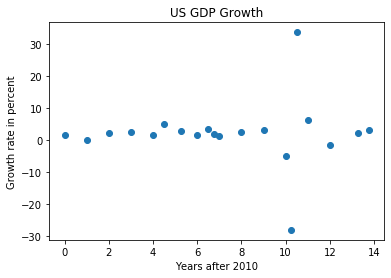

In [100]:
#This is a scatter plot of each of the data points
plt.scatter(x,y)
plt.title("US GDP Growth")
plt.ylabel("Growth rate in percent")
plt.xlabel("Years after 2010")

The first method used to interpolate the US GDP grwoth data will be the cubic spline - it creates a third degree polynomial between each of hte data points, and generates 100 x-values and their corresponnding y-value for every increase by 1 year in the original x array for smoothness. 

Setting up the cubic spline polynomial requires setting up four vectors - the subdiagonal, the main diagonal, the superdiagonal, and the right-hand side vector.

For n datapoints, the cupic spline solves for n-1 interpolating lines, and for 100 * (xf - xi) data points. In this context, there are 55 data points, so the system will solve for 54 cureves. The change in x is 13.75 years, so the cubic spline will solve for 1375 data points including the original x-values and values in between for smoothness.

This method requires 2 conditions: the continuity conditions and the boundary consitions. The continuity condition requires that there can be a continuous line in between two points, and the boundary condition requires that the second derivatives at the edge points are 0.

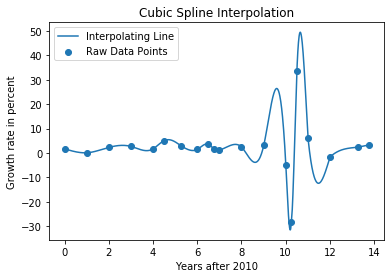

In [106]:
import numpy as np
import matplotlib.pyplot as plt
#The intention of this function is to set up a "Tridiagonal matrix" consisting of a subdiagonal, a
#main diagonal, a super diagonal, and a right hand side vector, and fill them with corresponding values of y
def setup_tridiagonal_matrix(x, y):
    n = len(x) # Array Length
    h = np.diff(x)  # Step sizes between data points
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])           # Right-hand side vector
    return A, B, C, D

#This function solves the matrix set up in the previous function to calculate the second derivative M used in
#the cubic spline

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i] # adds values from each matrix to returned array
    return x


#This function uses the "m" array to solve for the y-values, and interpolate between 100 values per 1 x-value
def custom_cubic_spline(x, y):
    evalx = x
    evaly = y
    a, b, c, d = setup_tridiagonal_matrix(x, y)# Sets up matrix using x and y arrays
    M = np.array([0.0, *thomas_algorithm(a, b, c, d), 0.0], dtype=float) # solves matrix and adds to M array
    length = 0
    for i in range(len(x)-1):
        length = length + (((x[i+1]-x[i]) * 100)) # for smoothness, adds x-values, 100 values per one x-value
    length = int(length)
    yreturn = np.zeros(length)
    xreturn = np.linspace(x[0], x[len(x)-1], length)
    prev_idx = 0
    for i in range(len(x)-1):
        xinterp = np.arange(x[i], x[i+1], 0.01)
        h = x[i+1]-x[i] # h value for each interval - represents change in x
        yreturn[prev_idx:prev_idx + int((x[i+1]-x[i]) * 100)] = (M[i]/(6 * h)) * (x[i+1]-xinterp)**3 + \
        (M[i+1]/(6 * h)) * (xinterp-x[i])**3 + (y[i]/h - (M[i] * h)/6) * (x[i+1]-xinterp) + \
        (y[i+1]/h - (M[i+1] * h)/6) * (xinterp-x[i]) # uses M and h to solve for y-values for each of the x-intervals
        prev_idx = prev_idx + int((x[i+1]-x[i]) * 100) #iterates through y linspace
            
        
    return xreturn, yreturn


x_interp, y_interp = custom_cubic_spline(x, y)

plt.scatter(x, y, label="Raw Data Points")
plt.plot(x_interp, y_interp, label="Interpolating Line")
plt.title("Cubic Spline Interpolation")
plt.ylabel("Growth rate in percent")
plt.xlabel("Years after 2010")
plt.legend()



This curve is smooth and goes through every point - including the 2020 Q2 point. It shows signs of Runge's phonomenon, which is the occurrence of oscillation toward the edges of intervals - this makes the model numerically unstable, as large outliers can cause large oscillations in the interpolating line - however, it is able to reach all points in the graph. For assessing general trends, a polynomial fit or a least squares approach may be a better fit, as it is not prone to such oscillations and is more numerically stable. However, those models may not be able to measure the impacts of events such as covid-19 on economic production.

Mean Squared Error Vandermonte Degree 4 Polynomial: 100.6298
R-squared Vandermonte Degree 4 Polynomial: 0.0035


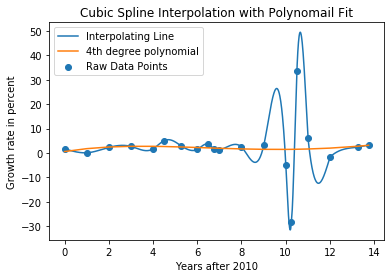

In [105]:
def create_vandermonde_matrix(degree, x):
    V = np.zeros(shape=((degree+1), len(x)))
    for i in range(degree+1):
        V[i] = (x.T ** i)
    V = V.T
    return V
def create_vandermonde_polynomial(degree, x, y):
    V = create_vandermonde_matrix(degree, x)
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)
    polynomial = np.zeros(len(x))
    for i in range(degree+1):
        polynomial += ((x**i) * coefficients[i])
    return polynomial

polynomial = create_vandermonde_polynomial(4, x, y)

plt.scatter(x, y, label="Raw Data Points")
plt.plot(x_interp, y_interp, label="Interpolating Line")
plt.plot(x, polynomial, label="4th degree polynomial")
plt.title("Cubic Spline Interpolation with Polynomail Fit")
plt.ylabel("Growth rate in percent")
plt.xlabel("Years after 2010")
plt.legend()

mse = np.mean((y-polynomial)**2)
print(f'Mean Squared Error Vandermonte Degree 4 Polynomial: {mse:.4f}')
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - polynomial)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared Vandermonte Degree 4 Polynomial: {r_squared:.4f}')





The vandermonde polynomial better captures the overall trend of the US economy - it does not oscillate with the occurrence of outliers like the cubic spline. Approximation allows for a better understanding of long term economic trends, while exact interpolation can better measure exact economic outlier events, such as covid-19.

m-value: -0.007627952755905512
Mean Squared Error Least Squares Linear Estimate: 2.0828
R-squared Least Squares Linear Estimate: 0.0004


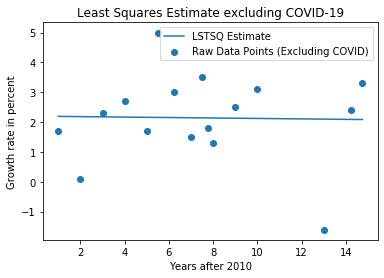

In [104]:
def my_lstsq(X, Y):
    n = len(X)
    sumX = np.sum(X)
    sumY = np.sum(Y)
    sumx2 = np.sum(X**2)
    sumA = np.sum(X * Y)
    m = (n * sumA - sumX * sumY) / (n * sumx2 - sumX**2)
    c = (sumY - m * sumX) / n
    return m, c

x_nocovid = np.array([1, 2, 3, 4, 5, 5.5, 6.25, 7, 7.5, 7.75, 8, 9, 10, 13, 14.25, 14.75])
y_nocovid = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3])
m, c = my_lstsq(x_nocovid, y_nocovid)
print(f"m-value: {m}")
plt.scatter(x_nocovid, y_nocovid, label="Raw Data Points (Excluding COVID)")
ylstsq = x_nocovid * m + c
plt.plot(x_nocovid, ylstsq, label="LSTSQ Estimate")
plt.title("Least Squares Estimate excluding COVID-19")
plt.ylabel("Growth rate in percent")
plt.xlabel("Years after 2010")
plt.legend()

mse = np.mean((y_nocovid - ylstsq)**2)
print(f'Mean Squared Error Least Squares Linear Estimate: {mse:.4f}')
ss_total = np.sum((y_nocovid - np.mean(y_nocovid))**2)
ss_res = np.sum((y_nocovid - ylstsq)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared Least Squares Linear Estimate: {r_squared:.4f}')


Due to the lack of correlation between each of the GDP growth rates per quarter, a least squares estimate may not be a good fit for the data - the slope is very close to 0, meaning the model cannot accurately capture a linear trend in the data. This method also requires the assumption that the economy remains stable, and would not be a reliable choice for an economist who aims to understand the impact of COVID-19.

Considering the nececessity to measure the impact of extermal events(such as pandemics) on the US economy, my recommendation will be the cubic spline interpolation. 

While the graph exhibits unreliabilites such as runge's phonomenon, it is able to visualize and interpolate the comparison of GDP growth between years after 2010, including major events such as COVID-19, for which it is crucial for economists to understand the impact of such events on economic production. In comparison,  the polynomial estimate, while able to measure general economic trends, is extremely unreliable when measuring the impact of external events - including COVID-19. The mean squared error for the polynomial fit including this is 100.63 percentiles on average, and its R-sqauared value is only 0.0035, indicating a poor fit. The least squares may perform better in the mean squared error measurement(only 2.08 percentiles on average away fron the true scores), meaning it also accurately measures the trend in data without external events. However, its R-sqaured value indicates an even worse fit (4 * 10^-4), and cannot accound for large changes in economic production. The cubic spline polynomial for this context would be the strognest fit to the data, as it displays a smooth curve while accurately interpolating values in between points, although extrapolating using this method is unreliable. 